### Story so far

## Setup

What we are really doing here is slowly peeling back layers of the data, asking simple questions first, and then letting those answers guide what we inspect next. Each plot or table is not just a result, but a clue about how the dataset behaves.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


### Story so far

## Load data

What we are really doing here is slowly peeling back layers of the data, asking simple questions first, and then letting those answers guide what we inspect next. Each plot or table is not just a result, but a clue about how the dataset behaves.


In [2]:
train = pd.read_json("train.json")
test  = pd.read_json("test.json")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()


Train shape: (21021, 4)
Test shape: (2000, 5)


,answer,type,context,question
0,"In 1512, Parliament passed a significant act t...",factual,During the Hundred Years' War a French attack ...,In what year did Parliament pass a notable law...
1,The Spanish and French were the ones who estab...,factual,"""By May 1539, Conquistador Hernando de Soto sk...",Who established early settlements in Florida
2,"Traditionally, monsoons in Punjab are expected...",factual,The onset of the southwest monsoon is anticipa...,When do monsoons traditionally happen in Punjab?
3,The media made the requests for Kondo to use o...,factual,Media requests at the trade show prompted Kond...,Who made the requests for Kondo to use orchest...
4,According to historians Robert Friedel and Pau...,factual,In addressing the question of who invented the...,How many inventors came up with electric lamps...


In [3]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21021 entries, 0 to 21020
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   answer    21021 non-null  object
 1   type      21021 non-null  object
 2   context   21021 non-null  object
 3   question  21021 non-null  object
dtypes: object(4)
memory usage: 657.0+ KB


In [4]:
train.isnull().sum()


,0
answer,0
type,0
context,0
question,0


In [5]:
def empty_count(col):
    return (train[col].astype(str).str.strip() == "").sum()

for c in ["context", "answer", "question", "type"]:
    print(c, "empty strings:", empty_count(c))


context empty strings: 1869
answer empty strings: 0
question empty strings: 0
type empty strings: 0


### Story so far

## Label Analysis

What we are really doing here is slowly peeling back layers of the data, asking simple questions first, and then letting those answers guide what we inspect next. Each plot or table is not just a result, but a clue about how the dataset behaves.


In [6]:
train["type"].value_counts(dropna=False)

,count
type,
factual,17431
contradiction,1818
irrelevant,1772


In [7]:
train["type"].value_counts(normalize=True, dropna=False)


,proportion
type,
factual,0.829218
contradiction,0.086485
irrelevant,0.084297


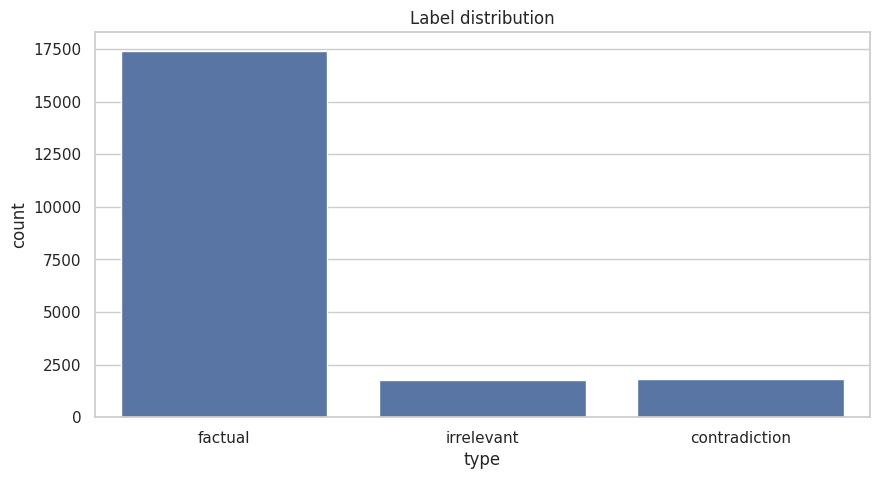

In [8]:
sns.countplot(data=train, x="type")
plt.title("Label distribution")
plt.show()


### Story so far

### Clean Labels

What we are really doing here is slowly peeling back layers of the data, asking simple questions first, and then letting those answers guide what we inspect next. Each plot or table is not just a result, but a clue about how the dataset behaves.


In [9]:
train["type_clean"] = (
    train["type"]
    .fillna("missing")
    .astype(str)
    .str.lower()
    .str.strip()
)

train["type_clean"].value_counts()


,count
type_clean,
factual,17431
contradiction,1818
irrelevant,1772


### Story so far

## Length Analysis

What we are really doing here is slowly peeling back layers of the data, asking simple questions first, and then letting those answers guide what we inspect next. Each plot or table is not just a result, but a clue about how the dataset behaves.


### Story so far

### Token proxies (word counts)

What we are really doing here is slowly peeling back layers of the data, asking simple questions first, and then letting those answers guide what we inspect next. Each plot or table is not just a result, but a clue about how the dataset behaves.


In [10]:
for col in ["context", "answer", "question"]:
    train[f"{col}_len"] = train[col].astype(str).str.split().str.len()


In [11]:
train[[c for c in train.columns if c.endswith("_len")]].describe()


,context_len,answer_len,question_len
count,21021.000000,21021.000000,21021.000000
mean,109.056848,14.325769,10.072261
std,57.754782,6.894050,3.586801
min,0.000000,1.000000,2.000000
25%,83.000000,10.000000,8.000000
50%,106.000000,13.000000,10.000000
75%,138.000000,18.000000,12.000000
max,653.000000,92.000000,34.000000


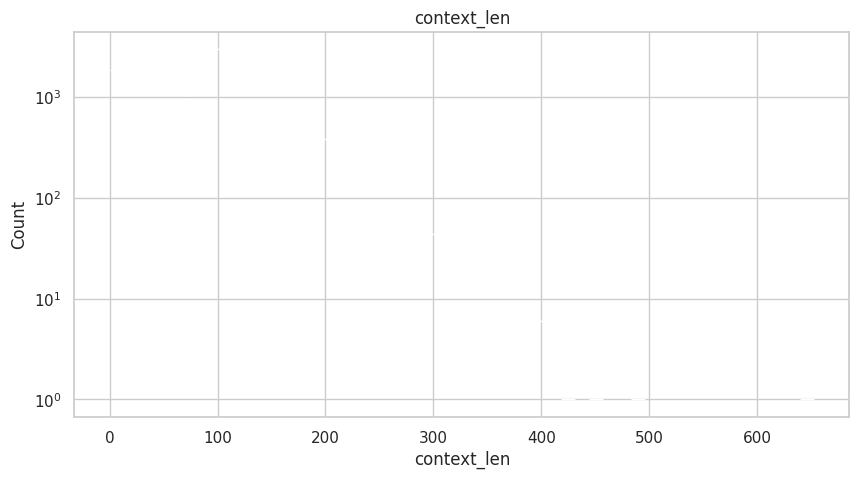

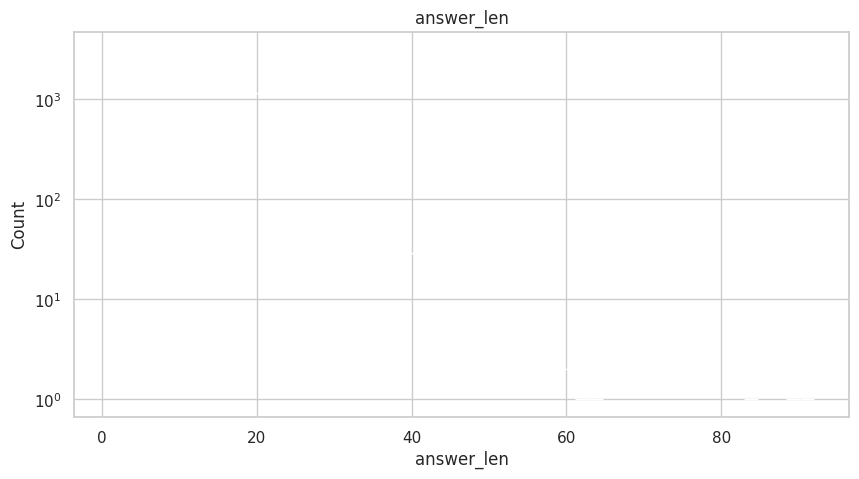

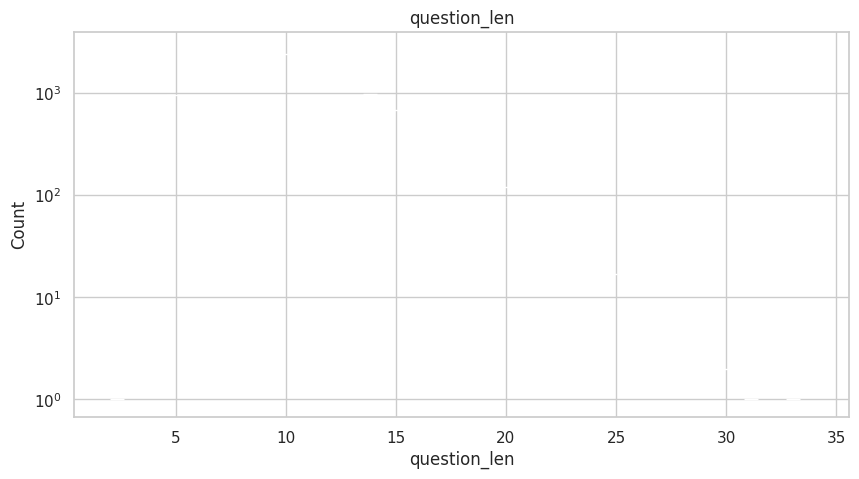

In [12]:
for col in ["context_len", "answer_len", "question_len"]:
    sns.histplot(train[col], bins=50, log_scale=(False, True))
    plt.title(col)
    plt.show()


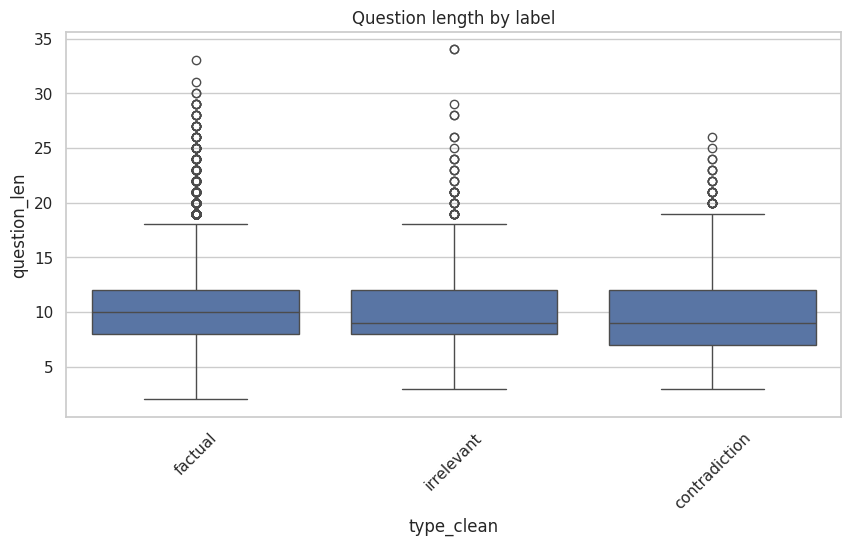

In [22]:
sns.boxplot(data=train, x="type_clean", y="question_len")
plt.xticks(rotation=45)
plt.title("Question length by label")
plt.show()


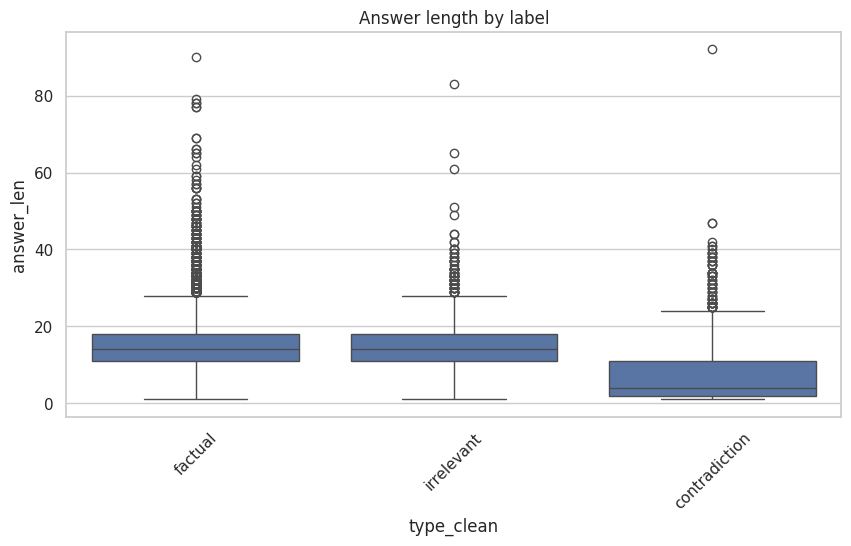

In [20]:
sns.boxplot(data=train, x="type_clean", y="answer_len")
plt.xticks(rotation=45)
plt.title("Answer length by label")
plt.show()


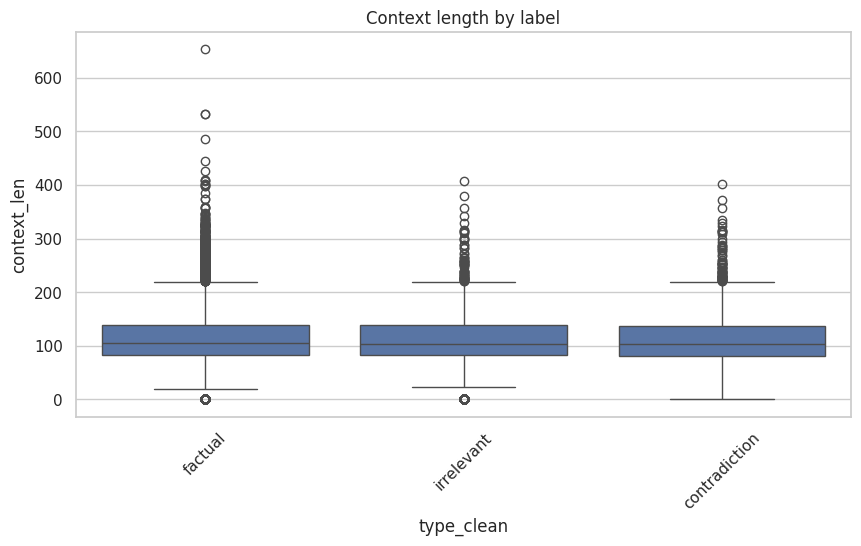

In [13]:
sns.boxplot(data=train, x="type_clean", y="context_len")
plt.xticks(rotation=45)
plt.title("Context length by label")
plt.show()


### Story so far

## Empty samples

What we are really doing here is slowly peeling back layers of the data, asking simple questions first, and then letting those answers guide what we inspect next. Each plot or table is not just a result, but a clue about how the dataset behaves.


In [14]:
empty_context = train[train["context"].astype(str).str.strip() == ""]
empty_context.shape

(1869, 8)

In [15]:
empty_context.sample(5)


,answer,type,context,question,type_clean,context_len,answer_len,question_len
7511,"In 2007, the Open Mobile Terminal Platform, a ...",factual,,In 2007 who endorsed micro-USB as the standard...,factual,0,25,16
8310,"The Greek Isles, specifically Cyprus, were col...",factual,,Which colonial enterprise for land was the Gre...,factual,0,11,12
2631,Pope Paul VI was the one who described the Ang...,irrelevant,,What two geographies did Frederick want for Pr...,irrelevant,0,16,8
13008,"During the early Ming Dynasty, Chinese merchan...",factual,,During The Early MIng Dynasty Chinese merchant...,factual,0,14,11
19614,Along with the ancient and early modern period...,irrelevant,,When did Hurricane Sandy strike New York?,irrelevant,0,16,7


In [16]:
def answer_in_context(row):
    return row["answer"].lower() in row["context"].lower()

train["answer_in_context"] = train.apply(answer_in_context, axis=1)
train["answer_in_context"].mean()


np.float64(0.007896865039722183)

In [24]:
train.query("answer_in_context == True")

,answer,type,context,question,type_clean,context_len,answer_len,question_len,answer_in_context
745,Africans,contradiction,For the anthropologists Lieberman and Jackson ...,"What would the diverse group of East Indians, ...",contradiction,188,1,19,True
1127,Most humans are not easily infected.,factual,Infection begins when an organism successfully...,What group is not easily infected?,factual,122,6,6,True
1777,Islamic influence in Tibet also came from Persia.,factual,Muslims have been living in Tibet since as ear...,Where did Islamic influence in Tibet come from?,factual,131,8,8,True
2132,0,contradiction,"In-mid 2015, China started the build-up of the...",How many BDS-3 satellites have been launched?,contradiction,39,1,7,True
2299,Homosexuality,contradiction,The SASO consists of 12 questions. Six of thes...,What questions corresponds to the homosexual o...,contradiction,87,1,7,True
...,...,...,...,...,...,...,...,...,...
20467,Beatrice,contradiction,"In 1853, Victoria gave birth to her eighth chi...",Who was Victoria's eighth child?,contradiction,120,1,5,True
20483,American Idol,contradiction,The two finalists in 2011 were Lauren Alaina a...,What is the name of the successful album that ...,contradiction,104,2,14,True
20657,10%,contradiction,Approximately 10% of the country's population ...,What percentage of the population continues to...,contradiction,42,1,10,True
20816,2,contradiction,"On July 11, 1877, a few days after the Bell Te...",How many children did Bell and Mabel have?,contradiction,156,1,8,True


In [17]:
train.groupby("type_clean")["answer_in_context"].mean()


,answer_in_context
type_clean,
contradiction,0.063256
factual,0.002926
irrelevant,0.000000


### Story so far

## N-gram leakage checks

What we are really doing here is slowly peeling back layers of the data, asking simple questions first, and then letting those answers guide what we inspect next. Each plot or table is not just a result, but a clue about how the dataset behaves.


In [18]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(texts, n=20):
    vec = CountVectorizer(stop_words="english", max_features=5000)
    X = vec.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    return vocab[np.argsort(freqs)[-n:]]

for lbl in train["type_clean"].unique():
    subset = train[train["type_clean"] == lbl]["answer"].astype(str)
    print(lbl, top_ngrams(subset))


factual ['period' 'population' 'approximately' '000' 'people' 'state' 'time'
 'term' 'century' 'war' 'world' 'located' 'called' 'states' 'united'
 'used' 'city' 'known' 'new' 'year']
irrelevant ['term' 'located' 'use' 'approximately' '000' 'place' 'people'
 'significant' 'century' 'world' 'population' 'war' 'called' 'used'
 'united' 'known' 'states' 'new' 'city' 'year']
contradiction ['century' 'united' 'term' 'period' 'american' 'actually' 'city' 'time'
 'previously' 'new' 'stated' 'fact' 'called' 'instead' 'used' '000' 'did'
 'modified' 'contradiction' 'answer']


### Story so far

## Test vs train drift

What we are really doing here is slowly peeling back layers of the data, asking simple questions first, and then letting those answers guide what we inspect next. Each plot or table is not just a result, but a clue about how the dataset behaves.


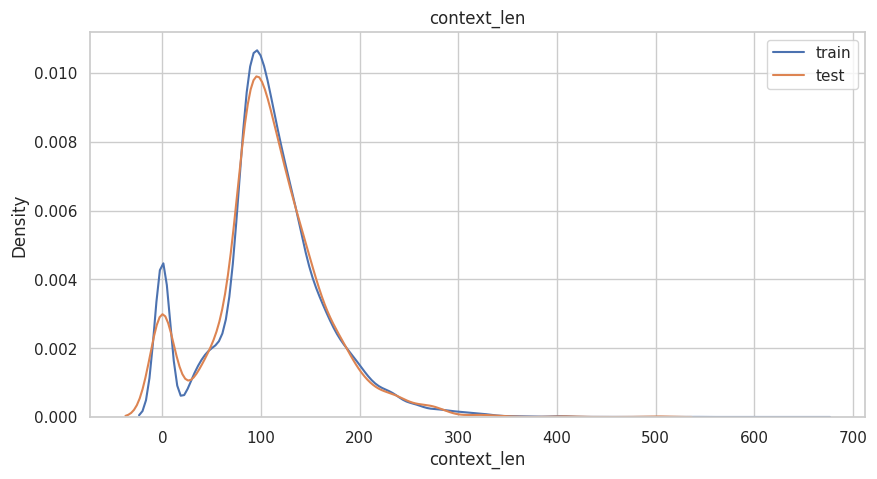

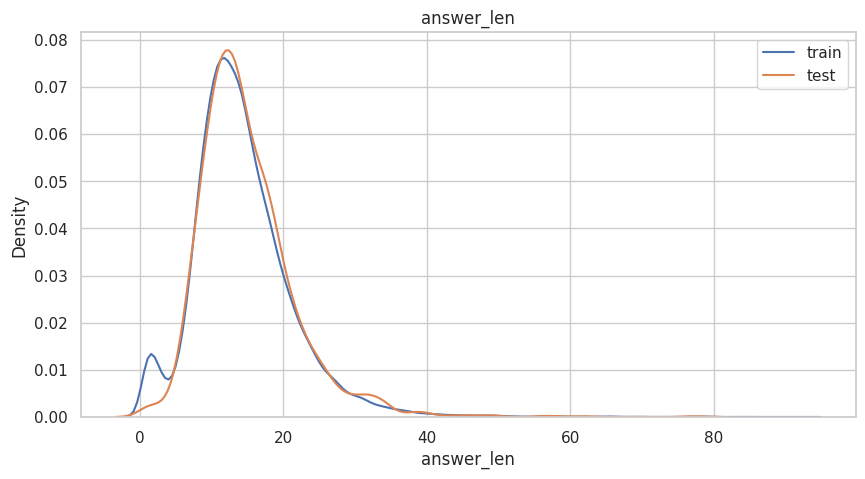

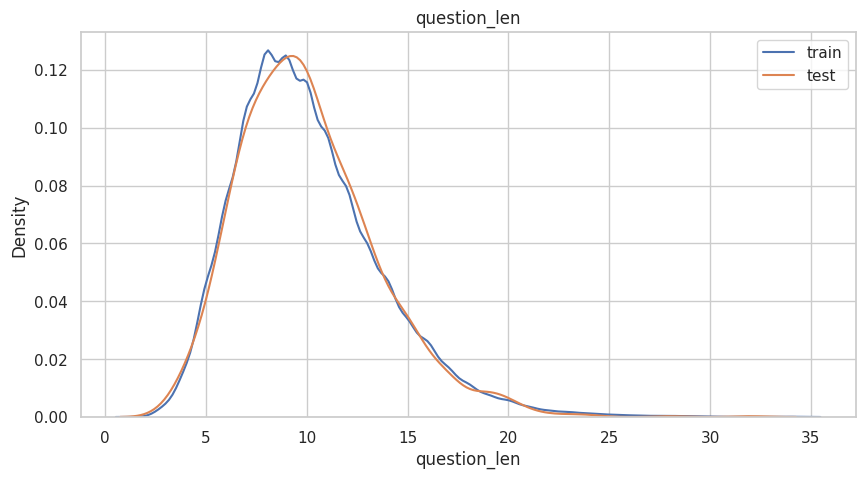

In [19]:
for col in ["context_len", "answer_len", "question_len"]:
    sns.kdeplot(train[col], label="train")
    sns.kdeplot(test[col.replace("_len","")].astype(str).str.split().str.len(), label="test")
    plt.title(col)
    plt.legend()
    plt.show()


### Story so far

###


context - answer embedding

context + question - answer embedding

question - answer embedding



What we are really doing here is slowly peeling back layers of the data, asking simple questions first, and then letting those answers guide what we inspect next. Each plot or table is not just a result, but a clue about how the dataset behaves.
